<a href="https://colab.research.google.com/github/chenyufei-lianxi/pytorch/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

In [37]:
#Convert MNIST Image Files into a Tensor of 4-Dimensions(# of images, Height, Width, Colour channel)
transform=transforms.ToTensor()

In [38]:
#Train Data
train_data=datasets.MNIST(root='/cnn_data',train=True,download=True,transform=transform)

In [39]:
#Test Data
test_data=datasets.MNIST(root='/cnn_data',train=False,download=True,transform=transform)

In [40]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /cnn_data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [41]:
# Create a small batch size for images,let's say 10
train_loader=DataLoader(train_data, batch_size=10,shuffle=True)
test_loader=DataLoader(test_data, batch_size=10,shuffle=False)

In [42]:
#Define our cnn model
#describe convolutional layer and what it's doing(2 convolutional layers)
# This is just an example in next video we'll build out the actual model
conv1=nn.Conv2d(1, 6, 3, 1)
conv2=nn.Conv2d(6, 16, 3, 1)

In [43]:
#Grab 1 MNIST record/image
for i,(X_Train,y_train) in enumerate(train_data):
  break

In [44]:
X_Train.shape

torch.Size([1, 28, 28])

In [45]:
x=X_Train.view(1,1,28,28)

In [46]:
#Perform our first convolution
x= F.relu(conv1(x)) #Rectified Linear unit for our activation function

In [47]:
# 1 single image, 6 is the filters we ask for, 26x26
x.shape

torch.Size([1, 6, 26, 26])

In [48]:
# pass thru the pooling layer
x = F.max_pool2d(x,2,2)# kernal of 2 and stride of 2

In [49]:
x.shape

torch.Size([1, 6, 13, 13])

In [50]:
# Do our second convolutional layer
x = F.relu(conv2(x))

In [51]:
x.shape # Again, we didn't set padding so we lose 2 pixles around the outside of the image

torch.Size([1, 16, 11, 11])

In [52]:
#Pooling layer
x=F.max_pool2d(x,2,2)

In [53]:
x.shape #11/2=5.5 but we have to round down, because you can't invent data to round up

torch.Size([1, 16, 5, 5])

In [54]:
((28-2)/2-2)/2

5.5

In [55]:
#Model Class
class ConvolutionalNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1=nn.Conv2d(1,6,3,1)
    self.conv2=nn.Conv2d(6,16,3,1)
    #Fully Connected Layer
    self.fc1=nn.Linear(5*5*16,120)
    self.fc2=nn.Linear(120,84)
    self.fc3=nn.Linear(84,10)

  def forward(self,X):
    X=F.relu(self.conv1(X))
    X=F.max_pool2d(X,2,2) # 2x2 kernal and stride 2
    #Second Pass
    X=F.relu(self.conv2(X))
    X=F.max_pool2d(X,2,2) # 2x2 kernal and stride 2
    X=X.view(-1,16*5*5)#negative one so that we can vary the batch size
    #Fully Connected Layer
    X=F.relu(self.fc1(X))
    X=F.relu(self.fc2(X))
    X=self.fc3(X)
    return F.log_softmax(X,dim=1)

In [56]:
#Create an Instance of our Model
torch.manual_seed(41)
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [57]:
#Loss Function Optimizer
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)# Smaller the learning Rate, longer its gonna take to train


In [58]:
import time
start_time=time.time()

# Create Variables To Tracks Things
epochs=5
train_losses=[]
test_losses=[]
train_correct=[]
test_correct=[]
#for loop of Epochs
for i in range(epochs):
  trn_corr=0
  tst_corr=0
  #Train
  for b,(X_train,y_train) in enumerate(train_loader):
    b+=1#Start our batches at 1
    y_pred=model(X_train)#get predicted values from the training set. Not flattened, is 2D
    loss=criterion(y_pred,y_train) #how off are we? Compare the predictions to correct answers in Y_train

    predicted=torch.max(y_pred.data,1)[1]#Add up the number of correct predictions. Indexed off the first point
    batch_corr=(predicted==y_train).sum() #how many we got correct from this batch, True=1,False=9,sum those up
    trn_corr+=batch_corr
    #Update our parameters
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    #Print out some results
    if b%600 ==0:
      print(f'Epoch:{i}  Batch:{b}  Loss:{loss.item()}')
  train_losses.append(loss)
  train_correct.append(trn_corr)

  #Test
  with torch.no_grad(): #No gradient so we don't update our weights and biases with test
    for b,(X_test,y_test) in enumerate(test_loader):
      y_val=model(X_test)
      predicted=torch.max(y_val.data,1)[1] #Adding up correct predictions
      tst_corr+=(predicted==y_test).sum()#T=1,F=0 and sum away
  loss=criterion(y_val,y_test)
  test_losses.append(loss)
  test_correct.append(tst_corr)




current_time=time.time()
total = current_time-start_time
print(f'Training Took:{total/60}minutes!')

Epoch:0  Batch:600  Loss:0.16236107051372528
Epoch:0  Batch:1200  Loss:0.15510495007038116
Epoch:0  Batch:1800  Loss:0.4651116728782654
Epoch:0  Batch:2400  Loss:0.17726822197437286
Epoch:0  Batch:3000  Loss:0.007429888937622309
Epoch:0  Batch:3600  Loss:0.37731707096099854
Epoch:0  Batch:4200  Loss:0.004938055761158466
Epoch:0  Batch:4800  Loss:0.0015040982980281115
Epoch:0  Batch:5400  Loss:0.06845302879810333
Epoch:0  Batch:6000  Loss:0.0004587689763866365
Epoch:1  Batch:600  Loss:0.002925408538430929
Epoch:1  Batch:1200  Loss:0.2792360186576843
Epoch:1  Batch:1800  Loss:0.0018853390356525779
Epoch:1  Batch:2400  Loss:0.0030733426101505756
Epoch:1  Batch:3000  Loss:0.024190708994865417
Epoch:1  Batch:3600  Loss:0.5062173008918762
Epoch:1  Batch:4200  Loss:0.02014169655740261
Epoch:1  Batch:4800  Loss:0.001421573688276112
Epoch:1  Batch:5400  Loss:0.0006034405087120831
Epoch:1  Batch:6000  Loss:0.1528162956237793
Epoch:2  Batch:600  Loss:0.07298740744590759
Epoch:2  Batch:1200  Loss:

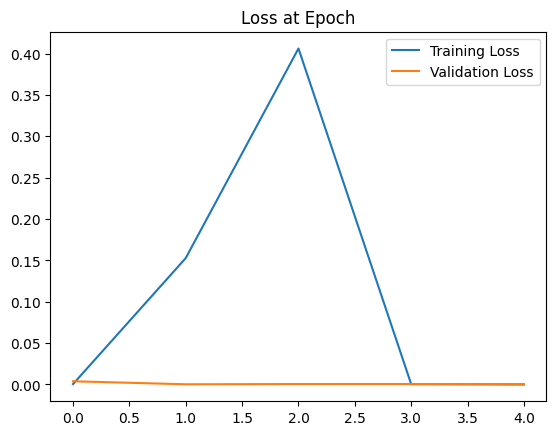

In [62]:
#Graph the loss at epoch
train_losses=[tl.item() for tl in train_losses]
plt.plot(train_losses,label='Training Loss')
plt.plot(test_losses,label='Validation Loss')
plt.title("Loss at Epoch")
plt.legend()

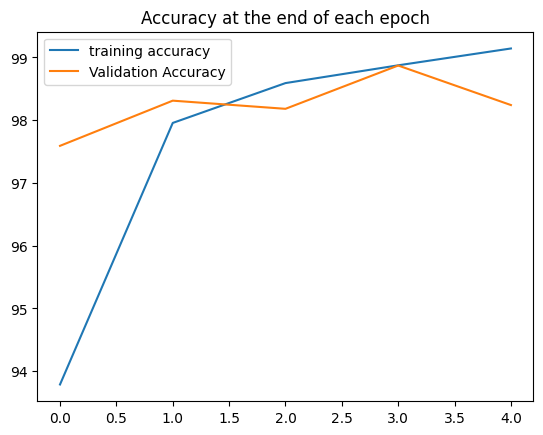

In [64]:
#graph the accuracy at the end of each epoch
plt.plot([t/600 for t in train_correct],label='training accuracy')
plt.plot([t/100 for t in test_correct],label='Validation Accuracy')
plt.title('Accuracy at the end of each epoch')
plt.legend()

In [65]:
test_load_everything=DataLoader(test_data,batch_size=10000,shuffle=False)


In [66]:
with torch.no_grad():
  correct=0
  for X_test, y_test in test_load_everything:
    y_val=model(X_test)
    predicted=torch.max(y_val,1)[1]
    correct+=(predicted==y_test).sum()

In [69]:
#Did for correct
correct.item()/len(test_data)*100

98.24000000000001

In [70]:
#Grab an image
test_data[4143] #Tensor with an image in it...at end, it shows the label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [71]:
#Grab just the data
test_data[4143][0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [72]:
#Reshape it
test_data[4143][0].reshape(28,28)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

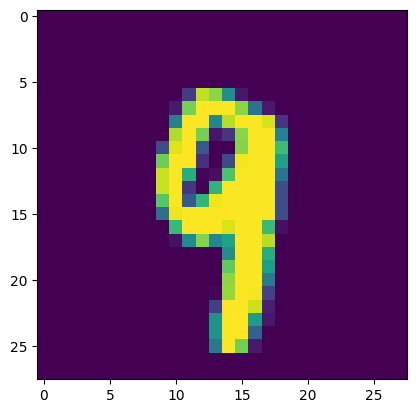

In [74]:
#Show the image
plt.imshow(test_data[4143][0].reshape(28,28))

In [75]:
#Pass the image thru our model
model.eval()
with torch.no_grad():
  new_prediction=model(test_data[4143][0].view(1,1,28,28))#batch size of 1, 1color channel,28x28image

In [76]:
#Check the new prediction...get probabilities
new_prediction

tensor([[-2.1717e+01, -1.6157e+01, -2.3344e+01, -1.3988e+01, -1.1304e+01,
         -1.8065e+01, -2.9872e+01, -1.2758e+01, -1.4630e+01, -1.6570e-05]])

In [78]:
new_prediction.argmax()

tensor(9)